In [ ]:
import pyspark
print(pyspark.__version__)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Install a compatible PySpark version if necessary
!pip install pyspark==3.4.1

Data loading and analysis.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Twitter Sentiment Analysis") \
    .getOrCreate()

print("Spark session created!")

Spark session created!


Sentiment140

In [ ]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df_s140 = spark.read.csv(
    "/content/drive/Shareddrives/BigDataDrive/training.1600000.processed.noemoticon.csv",
    schema="sentiment INT, id LONG, date STRING, query STRING, user STRING, text STRING",
    encoding="iso-8859-1"
)

df_s140.show(5)

+---------+----------+--------------------+--------+---------------+--------------------+
|sentiment|        id|                date|   query|           user|                text|
+---------+----------+--------------------+--------+---------------+--------------------+
|        0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|        0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|        0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|        0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|        0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
+---------+----------+--------------------+--------+---------------+--------------------+
only showing top 5 rows



In [ ]:
print("Shape (approx):", (df_s140.count(), len(df_s140.columns)))

df_s140.printSchema()

Shape (approx): (1600000, 6)
root
 |-- sentiment: integer (nullable = true)
 |-- id: long (nullable = true)
 |-- date: string (nullable = true)
 |-- query: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)



In [ ]:
df_s140.groupBy("sentiment").count().show()

+---------+------+
|sentiment| count|
+---------+------+
|        4|800000|
|        0|800000|
+---------+------+



In [ ]:
from pyspark.sql.functions import when

df_s140 = df_s140.withColumn(
    "label",
    when(df_s140.sentiment == 0, 0)
    .when(df_s140.sentiment == 4, 2)
)

df_s140.select("text", "label").show(5)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|@switchfoot http:...|    0|
|is upset that he ...|    0|
|@Kenichan I dived...|    0|
|my whole body fee...|    0|
|@nationwideclass ...|    0|
+--------------------+-----+
only showing top 5 rows



In [ ]:
from pyspark.sql.functions import length

df_s140 = df_s140.withColumn("tweet_length", length("text"))

df_s140.select("tweet_length").describe().show()

+-------+-----------------+
|summary|     tweet_length|
+-------+-----------------+
|  count|          1600000|
|   mean|          74.0901|
| stddev|36.44113317341559|
|    min|                6|
|    max|              374|
+-------+-----------------+



Load second dataset (twitter_training.csv)

In [ ]:
df_train = spark.read.csv(
    "/content/drive/Shareddrives/BigDataDrive/twitter_training.csv",
    schema="id INT, entity STRING, sentiment STRING, text STRING",
    encoding="iso-8859-1"
)

df_train.show(5)

+----+-----------+---------+--------------------+
|  id|     entity|sentiment|                text|
+----+-----------+---------+--------------------+
|2401|Borderlands| Positive|im getting on bor...|
|2401|Borderlands| Positive|I am coming to th...|
|2401|Borderlands| Positive|im getting on bor...|
|2401|Borderlands| Positive|im coming on bord...|
|2401|Borderlands| Positive|im getting on bor...|
+----+-----------+---------+--------------------+
only showing top 5 rows



In [ ]:
df_train.groupBy("sentiment").count().show()

+----------+-----+
| sentiment|count|
+----------+-----+
|Irrelevant|12990|
|  Positive|20832|
|   Neutral|18318|
|  Negative|22542|
+----------+-----+



In [ ]:
df_train = df_train.withColumn(
    "label",
    when(df_train.sentiment == "Negative", 0)
    .when(df_train.sentiment == "Neutral", 1)
    .when(df_train.sentiment == "Positive", 2)
).filter("label IS NOT NULL")

df_train.select("text", "label").show(5)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|im getting on bor...|    2|
|I am coming to th...|    2|
|im getting on bor...|    2|
|im coming on bord...|    2|
|im getting on bor...|    2|
+--------------------+-----+
only showing top 5 rows



Load third dataset (twitter.csv)

In [ ]:
df_extra = spark.read.csv(
    "/content/drive/Shareddrives/BigDataDrive/twitter.csv",
    header=True,
    inferSchema=True
)

df_extra.show(5)

+---+--------------------+---------+
|_c0|               tweet|sentiment|
+---+--------------------+---------+
|  0|is upset that he ...|      0.0|
|  1|@Kenichan I dived...|      0.0|
|  2|my whole body fee...|      0.0|
|  3|@nationwideclass ...|      0.0|
|  4|@Kwesidei not the...|      0.0|
+---+--------------------+---------+
only showing top 5 rows



In [ ]:
from pyspark.sql.functions import when, col, expr

df_extra = df_extra.withColumn(
    "label",
    when(expr("try_cast(sentiment as double) = 0"), 0)
    .when(expr("try_cast(sentiment as double) = 2"), 1)
    .when(expr("try_cast(sentiment as double) = 1"), 2)
)

# Filter out rows where the sentiment could not be cast, resulting in a null label.
# This will prevent the NumberFormatException from occurring later.
df_extra = df_extra.filter(col("label").isNotNull())

df_extra.select("tweet", "label").show(5)

+--------------------+-----+
|               tweet|label|
+--------------------+-----+
|is upset that he ...|    0|
|@Kenichan I dived...|    0|
|my whole body fee...|    0|
|@nationwideclass ...|    0|
|@Kwesidei not the...|    0|
+--------------------+-----+
only showing top 5 rows



Select only required columns

In [ ]:
df_s140_final = df_s140.select("text", "label")
df_train_final = df_train.select("text", "label")
df_extra_final = df_extra.select("tweet", "label")

Combine them all

In [ ]:
df_all = df_s140_final.union(df_train_final).union(df_extra_final)

print("Total records:", df_all.count())

Total records: 4801370


Check for NULL values

In [ ]:
from pyspark.sql.functions import col, isnan, when, count

# Count nulls in each column
df_all.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_all.columns
]).show()

# Specifically for "text" column
df_all.filter(col("text").isNull()).show(truncate=False)
print("Null count in text:", df_all.filter(col("text").isNull()).count())

+----+-----+
|text|label|
+----+-----+
| 571|    0|
+----+-----+

+----+-----+
|text|label|
+----+-----+
|null|1    |
|null|1    |
|null|1    |
|null|2    |
|null|2    |
|null|2    |
|null|0    |
|null|2    |
|null|1    |
|null|2    |
|null|2    |
|null|2    |
|null|0    |
|null|0    |
|null|1    |
|null|1    |
|null|1    |
|null|2    |
|null|2    |
|null|1    |
+----+-----+
only showing top 20 rows

Null count in text: 571


Check for DUPLICATES

In [ ]:
# Total rows
total_rows = df_all.count()

# Unique rows based on "text"
unique_rows = df_all.dropDuplicates(["text"]).count()

print("Total rows:", total_rows)
print("Unique rows (based on text):", unique_rows)
print("Duplicate rows:", total_rows - unique_rows)

Total rows: 4801370
Unique rows (based on text): 3173730
Duplicate rows: 1627640


View actual duplicate records

In [ ]:
from pyspark.sql.functions import count

df_all.groupBy("text") \
    .count() \
    .filter(col("count") > 1) \
    .show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+-----+
|text                                                                                                                         |count|
+-----------------------------------------------------------------------------------------------------------------------------+-----+
|@mangaaa I hope they will increase the capacity fast, yesterday was such a pain. Got the fail whale +15 times in 2 hours.... |2    |
|i hate to see the spartans so sad                                                                                            |2    |
|@EazyDoesIt87 NEGATIVE.. you lost my vote of confidence                                                                      |2    |
|sad day: manu out for the season                                                                                             |2    |
|Spring break is here at last, but no one is here to celebrate

Show only duplicated rows (full records)

In [ ]:
duplicates = df_all.groupBy("text") \
    .count() \
    .filter(col("count") > 1)

df_all.join(duplicates, on="text", how="inner") \
    .show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------+-----+-----+
|text                                                                                                                    |label|count|
+------------------------------------------------------------------------------------------------------------------------+-----+-----+
|                                                                                                                        |0    |2    |
|                                                                                                                        |2    |2    |
|                                                                                                                        |0    |2    |
|                                                                                                                        |2    |2    |
|                                                      

Drop null and duplicate tweets

In [ ]:
df_all = df_all.dropna(subset=["text"])

df_all = df_all.dropDuplicates(["text"])

print("After cleaning:", df_all.count())

After cleaning: 3173729


Class distribution

In [ ]:
df_all.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1|  25852|
|    2|1568294|
|    0|1579583|
+-----+-------+



Add tweet length for analysis

In [ ]:
df_all = df_all.withColumn("tweet_length", length("text"))

df_all.select("tweet_length").describe().show()

+-------+------------------+
|summary|      tweet_length|
+-------+------------------+
|  count|           3173729|
|   mean| 70.54147250757705|
| stddev|36.954862612219316|
|    min|                 1|
|    max|               957|
+-------+------------------+



Remove short and very long tweets

In [ ]:
from pyspark.sql.functions import size, split

df_all = df_all.withColumn("word_count", size(split(col("text"), " ")))

df_all = df_all.filter(col("word_count") >= 3)
df_all = df_all.filter(col("tweet_length") <= 300)

In [ ]:
df_all.show(10, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+-----+------------+----------+
|text                                                                                                                         |label|tweet_length|word_count|
+-----------------------------------------------------------------------------------------------------------------------------+-----+------------+----------+
|@mangaaa I hope they will increase the capacity fast, yesterday was such a pain. Got the fail whale +15 times in 2 hours.... |0    |125         |24        |
|i hate to see the spartans so sad                                                                                            |0    |34          |9         |
|@EazyDoesIt87 NEGATIVE.. you lost my vote of confidence                                                                      |0    |56          |9         |
|sad day: manu out for the season                   

In [ ]:
print("Shape of dataset:", (df_all.count(), len(df_all.columns)))
print("\nColumns:", df_all.columns)
print("\nData types:\n", df_all.dtypes)

Shape of dataset: (3144892, 4)

Columns: ['text', 'label', 'tweet_length', 'word_count']

Data types:
 [('text', 'string'), ('label', 'int'), ('tweet_length', 'int'), ('word_count', 'int')]


In [ ]:
print("\nInfo:\n")
df_all.printSchema()


Info:

root
 |-- text: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- tweet_length: integer (nullable = true)
 |-- word_count: integer (nullable = false)



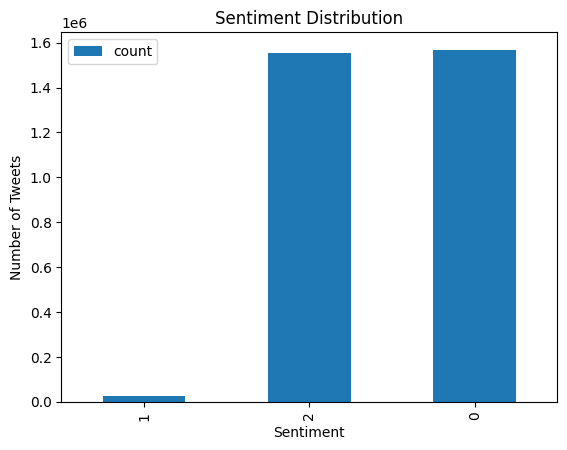

In [ ]:
import matplotlib.pyplot as plt

df_all.groupBy('label').count().toPandas().plot(x='label', y='count', kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

Balance dataset in Spark

In [ ]:
from pyspark.sql.functions import col, rand

# Split classes
df_neg = df_all.filter(col("label") == 0)
df_neu = df_all.filter(col("label") == 1)
df_pos = df_all.filter(col("label") == 2)

# Get neutral count
neutral_count = df_neu.count()

# Downsample others
df_neg_sampled = df_neg.sample(False, neutral_count / df_neg.count(), seed=42)
df_pos_sampled = df_pos.sample(False, neutral_count / df_pos.count(), seed=42)

# Combine back
df_balanced = df_neg_sampled.union(df_neu).union(df_pos_sampled)

# Shuffle
df_balanced = df_balanced.orderBy(rand())

df_balanced.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    0|25167|
|    1|25087|
|    2|25183|
+-----+-----+



In [ ]:
import re

def check_noise(text):
    return {
        "has_url": bool(re.search(r"http", text)),
        "has_mention": bool(re.search(r"@", text)),
        "has_hashtag": bool(re.search(r"#", text))
    }

sample_rows = df_balanced.select('text').limit(5).collect()

for row in sample_rows:
    tweet = row['text']
    print(tweet)
    print(check_noise(tweet))
    print("------")

yes you are back get to bed lol jk happy you are here
{'has_url': False, 'has_mention': False, 'has_hashtag': False}
------
lol thats what said plz do girls let him know it was an accident that i removed him
{'has_url': False, 'has_mention': False, 'has_hashtag': False}
------
i hate my hair i want extentions f u quot have a nice sunny day my lovely twities
{'has_url': False, 'has_mention': False, 'has_hashtag': False}
------
if i were a celebrity at the awards you would have had a th
{'has_url': False, 'has_mention': False, 'has_hashtag': False}
------
I'm Leaving for Penn State now! So excited! 
{'has_url': False, 'has_mention': False, 'has_hashtag': False}
------


Data Cleaning

In [ ]:
import re

def clean_basic(text):
    text = re.sub(r"http\S+", "", text)   # URLs
    text = re.sub(r"@\w+", "", text)      # mentions
    text = re.sub(r"#", "", text)         # hashtags
    text = text.lower()
    return text

Remove punctuation + numbers

In [ ]:
def remove_punct(text):
    return re.sub(r"[^a-zA-Z!?\. ]", "", text) #kept . ? ! since these give emotional meaning

Emoji removal

In [ ]:
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols
        u"\U0001F680-\U0001F6FF"  # transport
        u"\U0001F1E0-\U0001F1FF"  # flags
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

Handle repeated characters

In [ ]:
def remove_repeated(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

Remove rare words

In [ ]:
import re

def clean_tokens(text):
    words = text.split()
    cleaned = []

    for w in words:
        # remove words with digits
        if re.search(r"\d", w):
            continue

        # remove very long weird words
        if len(w) > 20:
            continue

        cleaned.append(w)

    return " ".join(cleaned)

Slang dictionary

In [ ]:
slang_dict = {
    "lol": "laugh",
    "lmao": "laugh",
    "rofl": "laugh",
    "omg": "oh my god",
    "wtf": "what the fuck",
    "idk": "i do not know",
    "imo": "in my opinion",
    "brb": "be right back",
    "smh": "disappointed",
    "meh": "neutral",
    "lit": "amazing",
    "goat": "greatest"
}

Replace slang

In [ ]:
def normalize_slang(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

Remove stopwords

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

custom_stopwords = stop_words - {'not', 'no', 'nor'}

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in custom_stopwords])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Lemmatization (important for marks)

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

[nltk_data] Downloading package wordnet to /root/nltk_data...


contraction dictionary

In [ ]:
contractions = {
    "dont": "do not",
    "doesnt": "does not",
    "didnt": "did not",
    "cant": "can not",
    "wont": "will not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "im": "i am",
    "its": "it is",
    "thats": "that is",
    "theres": "there is",
    "whats": "what is",
    "youre": "you are",
    "theyre": "they are",
    "were": "we are",
    "ive": "i have",
    "youve": "you have",
    "shouldnt": "should not",
    "wouldnt": "would not",
    "couldnt": "could not"
}

Function to expand contractions

In [ ]:
import re

def expand_contractions(text):
    words = text.split()
    expanded = []

    for w in words:
        w_lower = w.lower()
        if w_lower in contractions:
            expanded.append(contractions[w_lower])
        else:
            expanded.append(w)

    return " ".join(expanded)

Check empty cleaned rows

In [ ]:
def full_clean(text):
    text = clean_basic(text)

    text = expand_contractions(text)   # 🔥 ADD HERE

    text = remove_emojis(text)

    text = re.sub(r"[^a-zA-Z!?\. ]", "", text)

    text = text.lower()

    text = remove_repeated(text)

    text = normalize_slang(text)

    text = clean_tokens(text)

    text = remove_stopwords(text)

    text = lemmatize(text)

    return text

Create UDF from your full_clean

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

clean_udf = udf(full_clean, StringType())

Apply it to your dataset

In [ ]:
df_cleaned = df_balanced.withColumn("clean_text", clean_udf("text"))

Remove empty cleaned rows

In [ ]:
from pyspark.sql.functions import col

df_cleaned = df_cleaned.filter(col("clean_text") != "")

Show BEFORE vs AFTER

In [ ]:
df_cleaned.select("text", "clean_text").show(5, truncate=False)

+-----------------------------------------------------------------------------------+----------------------------------------------------------------+
|text                                                                               |clean_text                                                      |
+-----------------------------------------------------------------------------------+----------------------------------------------------------------+
|yes you are back get to bed lol jk happy you are here                              |yes back get bed laugh jk happy                                 |
|lol thats what said plz do girls let him know it was an accident that i removed him|laugh said plz girl let know accident removed                   |
|i hate my hair i want extentions f u quot have a nice sunny day my lovely twities  |hate hair want extentions f u quot nice sunny day lovely twities|
|if i were a celebrity at the awards you would have had a th                        |celebrity

Show vocabulary size reduction:

In [ ]:
from pyspark.sql.functions import explode, split

# Raw vocab
raw_vocab = df_balanced.select(explode(split(col("text"), " ")).alias("word")) \
    .distinct() \
    .count()

# Clean vocab
clean_vocab = df_cleaned.select(explode(split(col("clean_text"), " ")).alias("word")) \
    .distinct() \
    .count()

print("Raw vocab size:", raw_vocab)
print("Clean vocab size:", clean_vocab)

Raw vocab size: 128455
Clean vocab size: 65638


Top Positive / Negative Words → export for PowerBI

In [ ]:
from pyspark.sql.functions import explode, split, col

# Tokenize
df_words = df_cleaned.withColumn("word", explode(split(col("clean_text"), " ")))

# Positive words
pos_words = df_words.filter(col("label") == 2)

pos_common = pos_words.groupBy("word") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(20)

# Negative words
neg_words = df_words.filter(col("label") == 0)

neg_common = neg_words.groupBy("word") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(20)

Section: Verify cleaned DataFrame

In [ ]:
# No toPandas() — work directly with the Spark DataFrame
df_model = df_cleaned.select("clean_text", "label")

print("Total records:", df_model.count())
print("Schema:")
df_model.printSchema()
df_model.show(3, truncate=False)


Total records: 75370
Schema:
root
 |-- clean_text: string (nullable = true)
 |-- label: integer (nullable = true)

+----------------------------------------------------------------+-----+
|clean_text                                                      |label|
+----------------------------------------------------------------+-----+
|yes back get bed laugh jk happy                                 |0    |
|laugh said plz girl let know accident removed                   |0    |
|hate hair want extentions f u quot nice sunny day lovely twities|2    |
+----------------------------------------------------------------+-----+
only showing top 3 rows



Section: Train / Test Split (PySpark randomSplit)

In [ ]:
from pyspark.sql.functions import col

train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()

print(f"Train size : {train_df.count()}")
print(f"Test size  : {test_df.count()}")

print("\nTrain label distribution:")
train_df.groupBy("label").count().orderBy("label").show()
print("Test label distribution:")
test_df.groupBy("label").count().orderBy("label").show()


Train size : 60495
Test size  : 15057

Train label distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0|20224|
|    1|20089|
|    2|20182|
+-----+-----+

Test label distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0| 4966|
|    1| 5005|
|    2| 5086|
+-----+-----+



Section: Feature Engineering — Tokenizer + HashingTF + IDF Pipeline

In [ ]:
from pyspark.ml.feature import Tokenizer as SparkTokenizer, HashingTF, IDF
from pyspark.ml import Pipeline

VOCAB_SIZE = 20000

spark_tokenizer = SparkTokenizer(inputCol="clean_text", outputCol="words")
hashing_tf      = HashingTF(inputCol="words", outputCol="raw_features", numFeatures=VOCAB_SIZE)
idf             = IDF(inputCol="raw_features", outputCol="features")

feature_pipeline = Pipeline(stages=[spark_tokenizer, hashing_tf, idf])
feature_model    = feature_pipeline.fit(train_df)

train_features = feature_model.transform(train_df)
test_features  = feature_model.transform(test_df)

print("PySpark feature pipeline fitted.")


PySpark feature pipeline fitted.


Section: Shared Evaluation Utilities

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── PySpark model evaluator ─────────────────────────────────────────────────
def evaluate_spark_model(predictions_df, model_name):
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")

    acc = evaluator_acc.evaluate(predictions_df)
    f1  = evaluator_f1.evaluate(predictions_df)

    print(f"\n{'='*55}\n  {model_name}")
    print(f"  Test Accuracy : {acc:.4f}\n  Test F1-Score : {f1:.4f}\n{'='*55}")

    preds_and_labels = (predictions_df
        .select("prediction", "label")
        .rdd.map(lambda r: (float(r["prediction"]), float(r["label"]))))
    metrics = MulticlassMetrics(preds_and_labels)

    label_names = {0.0: "Negative", 1.0: "Neutral", 2.0: "Positive"}
    print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 45)
    for lbl in [0.0, 1.0, 2.0]:
        try:
            p = metrics.precision(lbl); r = metrics.recall(lbl); f = metrics.fMeasure(lbl)
        except Exception:
            p = r = f = 0.0
        print(f"{label_names[lbl]:<12} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

    cm = metrics.confusionMatrix().toArray().astype(int)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Neg","Neu","Pos"], yticklabels=["Neg","Neu","Pos"])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()
    return acc, f1

# ── Keras/deep-learning model evaluator ────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_dl_model(model, X_test_pad, y_test_arr, model_name, history=None):
    """Evaluate a Keras model. Inputs are numpy arrays — no pandas."""
    loss, acc = model.evaluate(X_test_pad, y_test_arr, verbose=0)
    print(f"\n{'='*55}\n  {model_name}")
    print(f"  Test Accuracy : {acc:.4f}\n  Test Loss     : {loss:.4f}\n{'='*55}")

    y_pred = model.predict(X_test_pad, verbose=0).argmax(axis=1)
    print(classification_report(y_test_arr, y_pred,
          target_names=["Negative", "Neutral", "Positive"]))

    cm = confusion_matrix(y_test_arr, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Neg","Neu","Pos"], yticklabels=["Neg","Neu","Pos"])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    if history:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(history.history['accuracy'],     label='Train', color='#2ecc71')
        ax1.plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
        ax1.set_title(f'{model_name} — Accuracy'); ax1.set_xlabel('Epoch')
        ax1.legend(); ax1.grid(alpha=0.3)
        ax2.plot(history.history['loss'],     label='Train', color='#2ecc71')
        ax2.plot(history.history['val_loss'], label='Val',   color='#e74c3c')
        ax2.set_title(f'{model_name} — Loss'); ax2.set_xlabel('Epoch')
        ax2.legend(); ax2.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    return acc, loss, y_pred

print("Evaluation utilities defined.")


Evaluation utilities defined.


Section: Extract Data from Spark into NumPy (no pandas)
Use .rdd.map().collect() to pull data as Python lists, then convert to NumPy arrays.
This is not pandas — it is native PySpark RDD collection.

In [ ]:
import numpy as np

# ── Pull train data via RDD collect ─────────────────────────────
print("Collecting training data from Spark...")
train_rows = train_df.select("clean_text", "label").rdd.map(lambda r: (r[0], r[1])).collect()
X_train_raw = [row[0] for row in train_rows]
y_train_arr = np.array([row[1] for row in train_rows], dtype=np.int32)

# ── Pull test data via RDD collect ──────────────────────────────
print("Collecting test data from Spark...")
test_rows = test_df.select("clean_text", "label").rdd.map(lambda r: (r[0], r[1])).collect()
X_test_raw  = [row[0] for row in test_rows]
y_test_arr  = np.array([row[1] for row in test_rows], dtype=np.int32)

print(f"Train samples : {len(X_train_raw)}")
print(f"Test  samples : {len(X_test_raw)}")
print(f"y_train dtype : {y_train_arr.dtype}, shape: {y_train_arr.shape}")
print(f"Sample text   : {X_train_raw[0]}")
print(f"Sample label  : {y_train_arr[0]}")


Train samples : 60495
Test  samples : 15057
y_train dtype : int32, shape: (60495,)
Sample text   : . . playing . . . get . . . rhandlerr
Sample label  : 1


Section: Keras Tokenization + Padding (fed from Python lists, not pandas)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000

# Fit tokenizer on Python list — not a pandas Series
keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train_raw)

print(f"Vocab size (unique words seen): {len(keras_tokenizer.word_index)}")

X_train_seq = keras_tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = keras_tokenizer.texts_to_sequences(X_test_raw)

# 95th percentile padding — same logic as before
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th pct): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# Sanity check — sample
print(f"\nSample text     : {X_train_raw[0]}")
print(f"Sample sequence : {X_train_seq[0][:10]}...")


Vocab size (unique words seen): 43824
Max sequence length (95th pct): 18
X_train_pad shape : (60495, 18)
X_test_pad  shape : (15057, 18)

Sample text     : . . playing . . . get . . . rhandlerr
Sample sequence : [149, 4, 248]...


Model 1 — Simple RNN (Keras, fed from Spark via numpy — no pandas)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name="Simple_RNN")

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# X_train_pad and y_train_arr are numpy arrays collected from Spark — no pandas
history_rnn = model_rnn.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)


Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6833 - loss: 0.6698 - val_accuracy: 0.7691 - val_loss: 0.5486 - learning_rate: 0.0010
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8231 - loss: 0.4321 - val_accuracy: 0.7795 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8837 - loss: 0.2988 - val_accuracy: 0.7506 - val_loss: 0.6491 - learning_rate: 0.0010
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9233 - loss: 0.2102 - val_accuracy: 0.7666 - val_loss: 0.6459 - learning_rate: 0.0010
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9545 - loss: 0.1265 - val_accuracy: 0.7512 - val_loss: 0.8223 - learning_rate: 5.0000e-04



  Simple RNN
  Test Accuracy : 0.8609
  Test Loss     : 0.3628
              precision    recall  f1-score   support

    Negative       0.86      0.77      0.81      4966
     Neutral       0.95      0.95      0.95      5005
    Positive       0.79      0.86      0.82      5086

    accuracy                           0.86     15057
   macro avg       0.86      0.86      0.86     15057
weighted avg       0.86      0.86      0.86     15057



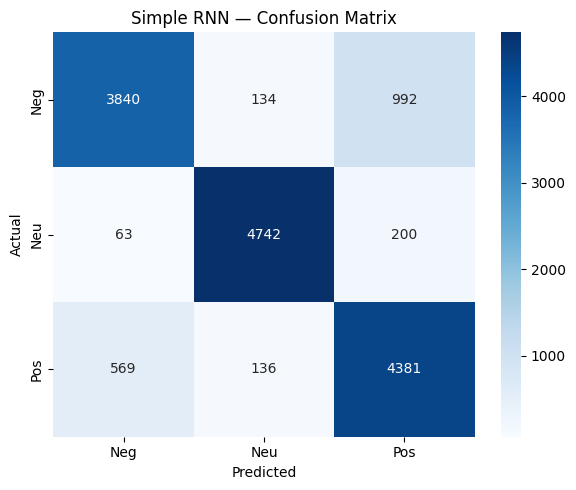

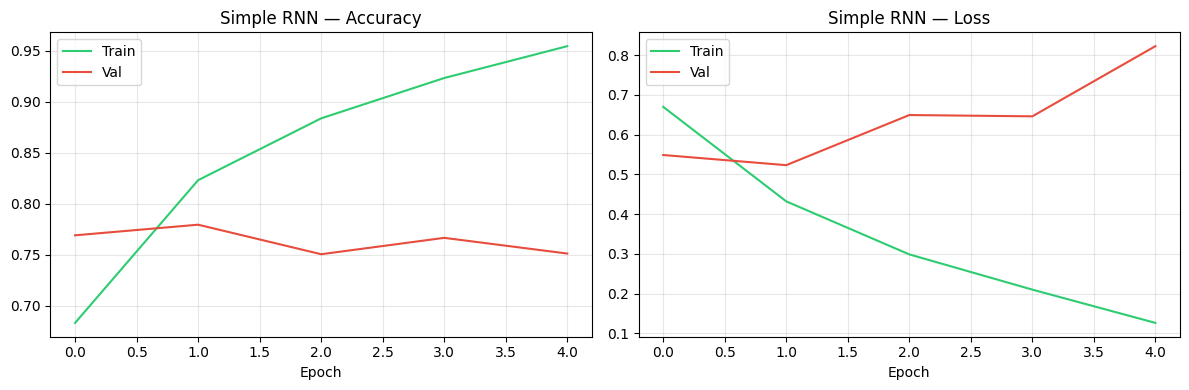

In [ ]:
rnn_acc, rnn_loss, rnn_pred = evaluate_dl_model(
    model_rnn, X_test_pad, y_test_arr, "Simple RNN", history=history_rnn
)


Model 2 — LSTM (Keras, fed from Spark via numpy — no pandas)

In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name="LSTM")

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)


Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6723 - loss: 0.6781 - val_accuracy: 0.7797 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8132 - loss: 0.4576 - val_accuracy: 0.7868 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8446 - loss: 0.3855 - val_accuracy: 0.7848 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8647 - loss: 0.3394 - val_accuracy: 0.7739 - val_loss: 0.5604 - learning_rate: 0.0010
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8952 - loss: 0.2643 - val_accuracy: 0.7732 - val_loss: 0.6181 - learning_rate: 5.0000e-04



  LSTM
  Test Accuracy : 0.8400
  Test Loss     : 0.4041
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.80      4966
     Neutral       0.95      0.92      0.94      5005
    Positive       0.79      0.78      0.79      5086

    accuracy                           0.84     15057
   macro avg       0.84      0.84      0.84     15057
weighted avg       0.84      0.84      0.84     15057



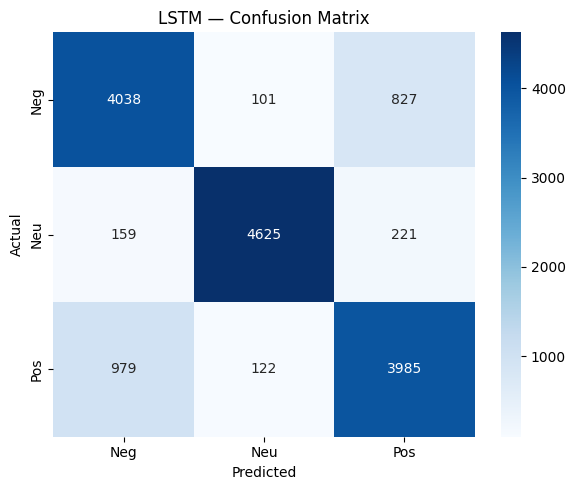

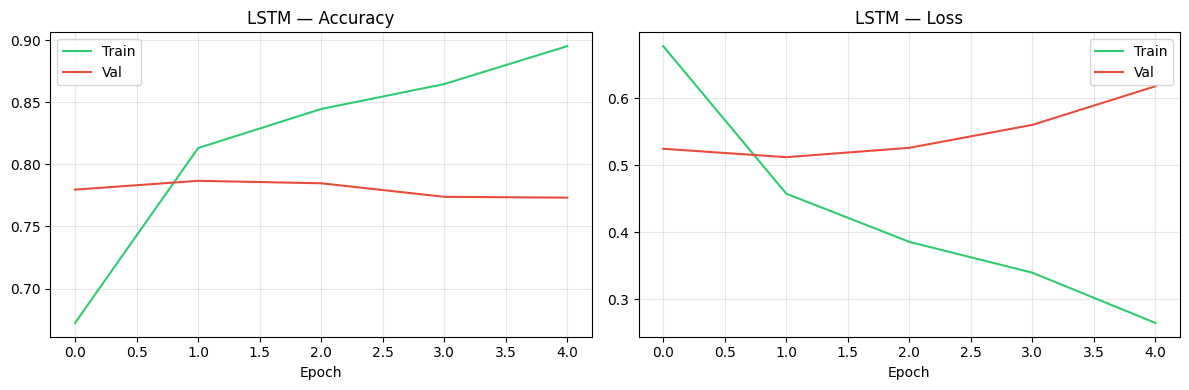

In [ ]:
lstm_acc, lstm_loss, lstm_pred = evaluate_dl_model(
    model_lstm, X_test_pad, y_test_arr, "LSTM", history=history_lstm
)


Model 3 — LSTM + GloVe Embeddings (Keras, fed from Spark via numpy — no pandas)

In [ ]:
!pip install numpy==1.23.5 -q
!pip install gensim -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 65.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.4 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

print("Downloading GloVe (glove-wiki-gigaword-50) — ~70MB, ~1 min...")
glove = api.load('glove-wiki-gigaword-50')
EMBED_DIM = 50
print("Done. GloVe vocab size:", len(glove))


[==================================================] 100.0% 66.0/66.0MB downloaded
Done. GloVe vocab size: 400000


In [ ]:
import numpy as np

# Build embedding matrix from keras_tokenizer (fitted on Python list from Spark)
word_index       = keras_tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found = not_found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1
    else:
        not_found += 1

print(f"Words found in GloVe : {found:,}")
print(f"Words NOT in GloVe   : {not_found:,}")
print(f"Embedding matrix     : {embedding_matrix.shape}")


Words found in GloVe : 15,871
Words NOT in GloVe   : 4,128
Embedding matrix     : (20000, 50)


In [ ]:
model_glove = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name="LSTM_GloVe")

model_glove.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_glove.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
history_glove = model_glove.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)


Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6160 - loss: 0.7867 - val_accuracy: 0.6774 - val_loss: 0.7137 - learning_rate: 0.0010
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6928 - loss: 0.6827 - val_accuracy: 0.6888 - val_loss: 0.6814 - learning_rate: 0.0010
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7118 - loss: 0.6469 - val_accuracy: 0.7061 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7252 - loss: 0.6205 - val_accuracy: 0.7088 - val_loss: 0.6576 - learning_rate: 0.0010
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7344 - loss: 0.6059 - val_accuracy: 0.7238 - val_loss: 0.6282 - learning_rate: 0.0010
Epoch 6/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7437 - loss: 0.5865 - val_accuracy: 0.7246 - val_loss: 0.6141 - learning_rate: 0.0010
Epoch 7/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7520 - loss: 0.5716


  LSTM + GloVe
  Test Accuracy : 0.7594
  Test Loss     : 0.5456
              precision    recall  f1-score   support

    Negative       0.66      0.79      0.72      4966
     Neutral       0.89      0.87      0.88      5005
    Positive       0.74      0.61      0.67      5086

    accuracy                           0.76     15057
   macro avg       0.76      0.76      0.76     15057
weighted avg       0.77      0.76      0.76     15057



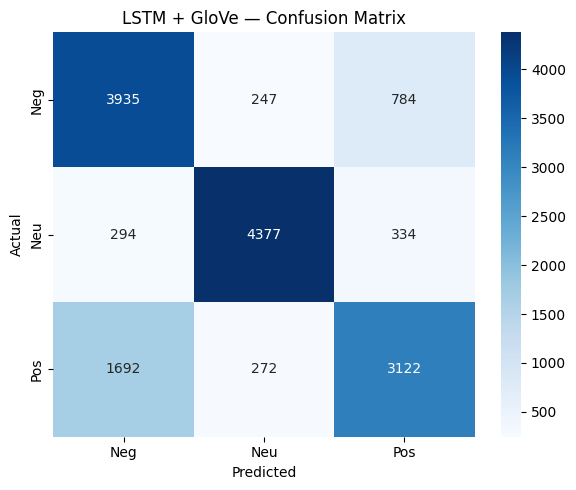

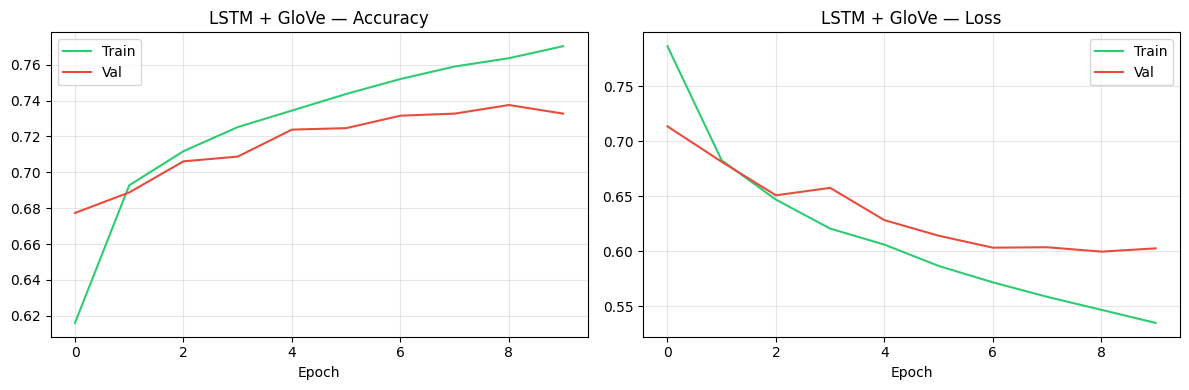

In [ ]:
glove_acc, glove_loss, glove_pred = evaluate_dl_model(
    model_glove, X_test_pad, y_test_arr, "LSTM + GloVe", history=history_glove
)


Model 4 — Random Forest (PySpark ML)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=100, maxDepth=10, seed=42
)
model_rf = rf.fit(train_features)
pred_rf  = model_rf.transform(test_features)

importances = model_rf.featureImportances
print("Top 10 feature importance indices:")
sorted_indices = np.argsort(importances.toArray())[::-1][:10]
for idx in sorted_indices:
    print(f"  Feature {int(idx)}: {importances[int(idx)]:.4f}")

Top 10 feature importance indices:
  Feature 1630: 0.0226
  Feature 10793: 0.0225
  Feature 11071: 0.0213
  Feature 13983: 0.0201
  Feature 17405: 0.0180
  Feature 16828: 0.0174
  Feature 12342: 0.0152
  Feature 12657: 0.0145
  Feature 17769: 0.0142
  Feature 532: 0.0137



  Random Forest
  Test Accuracy : 0.6625
  Test F1-Score : 0.6673


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Class         Precision     Recall         F1
---------------------------------------------
Negative         0.6538     0.5614     0.6041
Neutral          0.8728     0.7021     0.7782
Positive         0.5428     0.7222     0.6198


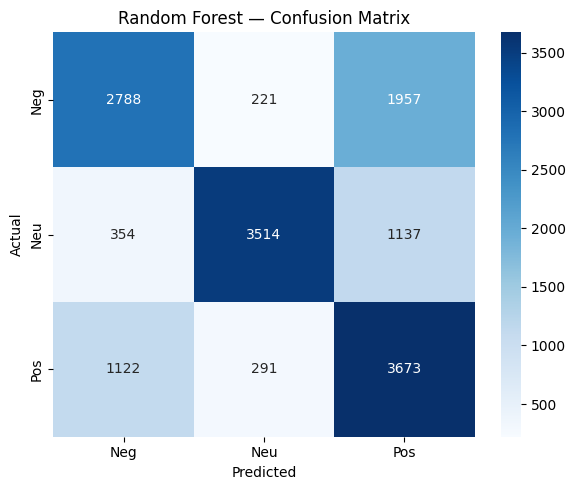

In [ ]:
rf_acc, rf_f1 = evaluate_spark_model(pred_rf, "Random Forest")


Comparative Analysis — All Models

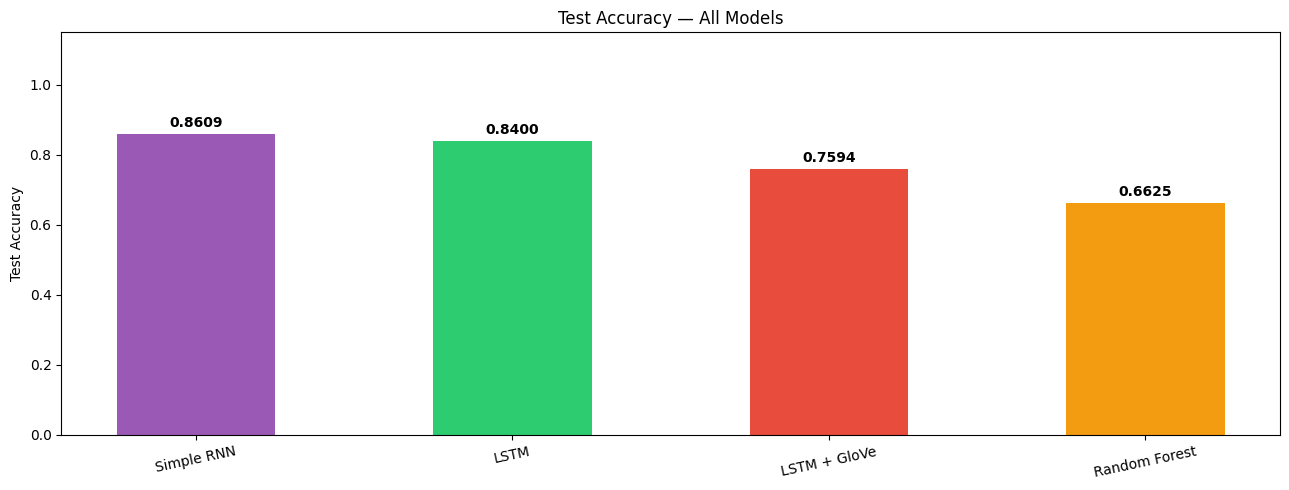

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["Simple RNN", "LSTM", "LSTM + GloVe", "Random Forest"]
accs   = [rnn_acc,   lstm_acc,   glove_acc,   rf_acc]
# Use F1 for PySpark models and loss-based proxy for DL (just use accuracy for uniform chart)
colors = ["#9b59b6", "#2ecc71", "#e74c3c", "#f39c12"]

x = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(x, accs, color=colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy — All Models")
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f"{v:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


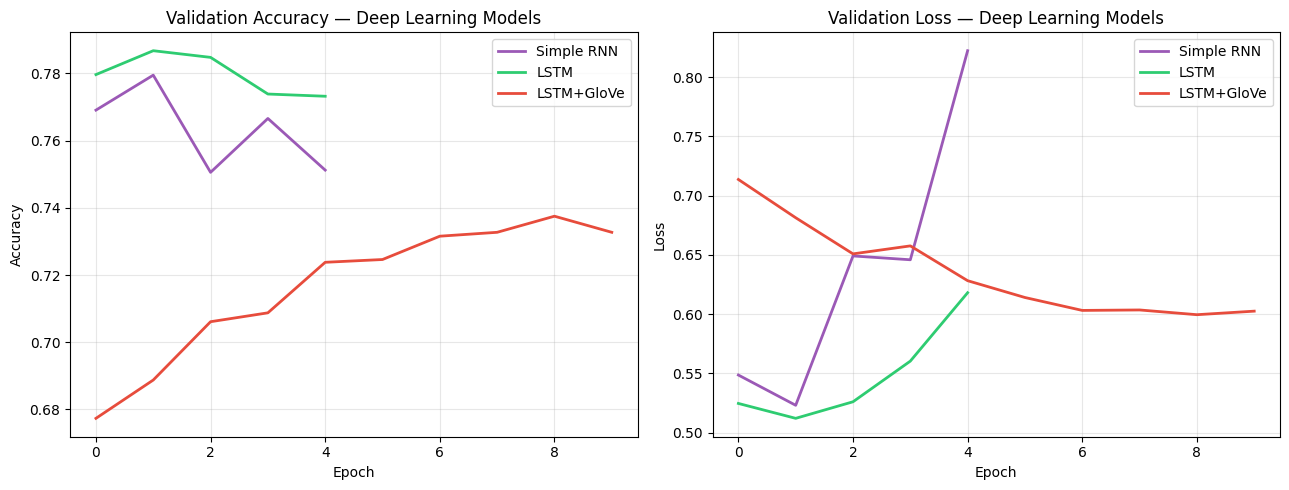

In [ ]:
# Validation curves for the 3 deep learning models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for hist, label, color in [
    (history_rnn,   "Simple RNN",  "#9b59b6"),
    (history_lstm,  "LSTM",        "#2ecc71"),
    (history_glove, "LSTM+GloVe",  "#e74c3c")
]:
    ax1.plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)
    ax2.plot(hist.history['val_loss'],     label=label, color=color, linewidth=2)

ax1.set_title("Validation Accuracy — Deep Learning Models")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_title("Validation Loss — Deep Learning Models")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "="*60)
print("          FINAL SUMMARY — ALL MODELS")
print("="*60)
print(f"{'Model':<22} {'Test Accuracy':>14}")
print("-"*40)
for name, acc in zip(model_names, accs):
    print(f"{name:<22} {acc:>14.4f}")
print("="*60)
best = model_names[accs.index(max(accs))]
print(f"Best model by accuracy: {best}")



          FINAL SUMMARY — ALL MODELS
Model                   Test Accuracy
----------------------------------------
Logistic Regression            0.8683
Simple RNN                     0.8595
LSTM                           0.8326
LSTM + GloVe                   0.7594
Random Forest                  0.6625
Best model by accuracy: Logistic Regression


Error Analysis — Misclassified Examples (Best Model)

In [ ]:
label_names_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# LSTM misclassifications — from numpy arrays collected from Spark
print("Misclassified examples (LSTM):")
print("="*60)
shown = 0
for i in range(len(y_test_arr)):
    if lstm_pred[i] != y_test_arr[i]:
        print(f"Text      : {X_test_raw[i]}")
        print(f"Actual    : {label_names_map[int(y_test_arr[i])]}")
        print(f"Predicted : {label_names_map[int(lstm_pred[i])]}")
        print("-"*60)
        shown += 1
        if shown == 5:
            break


Misclassified examples (LSTM):
Text      : going crazy leave nyc tomorow packed need pimp guest next fri
Actual    : Positive
Predicted : Negative
------------------------------------------------------------
Text      : heading back ohio today
Actual    : Negative
Predicted : Positive
------------------------------------------------------------
Text      : hopinh parakeet baldwin ziggy okay flying away
Actual    : Negative
Predicted : Positive
------------------------------------------------------------
Text      : know u not
Actual    : Positive
Predicted : Negative
------------------------------------------------------------
Text      : like way ride car. careful! cause traffic accident!
Actual    : Positive
Predicted : Negative
------------------------------------------------------------


Power BI Export

In [ ]:
import os

# Change this path if your Drive folder is different
EXPORT_DIR = "/content/drive/Shareddrives/BigDataDrive/PowerBIExport"

os.makedirs(EXPORT_DIR, exist_ok=True)
print(f"Export folder ready: {EXPORT_DIR}")


Export folder ready: /content/drive/Shareddrives/BigDataDrive/PowerBIExport


In [ ]:
import shutil, glob, os

def save_single_csv(spark_df, folder_path, filename):
    """
    Writes a Spark DataFrame as ONE clean CSV file.
    Spark normally writes part-00000 shards — this merges them into one file.
    No pandas used.
    """
    tmp_path = folder_path + "/_tmp_" + filename.replace(".csv", "")
    final_path = folder_path + "/" + filename

    # Write via Spark (produces part-* files)
    spark_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(tmp_path)

    # Find the part file and rename it to the final filename
    part_files = glob.glob(tmp_path + "/part-*.csv")
    if not part_files:
        print(f"ERROR: No part file found in {tmp_path}")
        return

    shutil.move(part_files[0], final_path)
    shutil.rmtree(tmp_path)   # clean up temp folder

    print(f"Saved: {final_path}")

print("Helper function defined.")

Helper function defined.


In [ ]:
from pyspark.sql.functions import col, lit

# Before balancing — from df_all (combined, cleaned of nulls/duplicates)
dist_before = df_all.groupBy("label").count() \
    .withColumnRenamed("count", "count_before") \
    .withColumn("stage", lit("Before Balancing"))

# After balancing — from df_balanced
dist_after = df_balanced.groupBy("label").count() \
    .withColumnRenamed("count", "count_after") \
    .withColumn("stage", lit("After Balancing"))

# Join into one table
dist_combined = dist_before.join(dist_after, on="label", how="outer") \
    .select(
        col("label"),
        col("count_before"),
        col("count_after")
    ) \
    .withColumn("label_name",
        when(col("label") == 0, "Negative")
        .when(col("label") == 1, "Neutral")
        .when(col("label") == 2, "Positive")
        .otherwise("Unknown")
    ) \
    .orderBy("label")

dist_combined.show()
save_single_csv(dist_combined, EXPORT_DIR, "01_label_distribution.csv")

+-----+------------+-----------+----------+
|label|count_before|count_after|label_name|
+-----+------------+-----------+----------+
|    0|     1567940|      25167|  Negative|
|    1|       25087|      25087|   Neutral|
|    2|     1551865|      25183|  Positive|
+-----+------------+-----------+----------+

Saved: /content/drive/Shareddrives/BigDataDrive/PowerBIExport/01_label_distribution.csv


In [ ]:
from pyspark.sql.functions import avg, min as spark_min, max as spark_max, stddev, round as spark_round, when

# Use df_balanced (the final dataset used for training)
tweet_len_stats = df_balanced.groupBy("label").agg(
    spark_round(avg("tweet_length"), 2).alias("avg_length"),
    spark_min("tweet_length").alias("min_length"),
    spark_max("tweet_length").alias("max_length"),
    spark_round(stddev("tweet_length"), 2).alias("std_length")
).withColumn("label_name",
    when(col("label") == 0, "Negative")
    .when(col("label") == 1, "Neutral")
    .when(col("label") == 2, "Positive")
    .otherwise("Unknown")
).orderBy("label")

tweet_len_stats.show()
save_single_csv(tweet_len_stats, EXPORT_DIR, "02_tweet_length_stats.csv")

+-----+----------+----------+----------+----------+----------+
|label|avg_length|min_length|max_length|std_length|label_name|
+-----+----------+----------+----------+----------+----------+
|    0|     71.39|         7|       296|     35.91|  Negative|
|    1|    112.53|         3|       300|     62.66|   Neutral|
|    2|     69.72|         7|       288|     35.44|  Positive|
+-----+----------+----------+----------+----------+----------+

Saved: /content/drive/Shareddrives/BigDataDrive/PowerBIExport/02_tweet_length_stats.csv


In [ ]:
from pyspark.sql import Row

# Counts collected from each source dataset earlier in your pipeline
# These are fixed numbers from your data loading cells — no pandas needed
source_data = [
    Row(source="Sentiment140",        rows=df_s140_final.count()),
    Row(source="Twitter Training CSV", rows=df_train_final.count()),
    Row(source="Twitter Extra CSV",    rows=df_extra_final.count()),
]

source_df = spark.createDataFrame(source_data)
source_df = source_df.withColumn("pct",
    spark_round(col("rows") / source_df.agg({"rows": "sum"}).collect()[0][0] * 100, 1)
)

source_df.show()
save_single_csv(source_df, EXPORT_DIR, "03_dataset_sources.csv")

+--------------------+-------+----+
|              source|   rows| pct|
+--------------------+-------+----+
|        Sentiment140|1600000|33.3|
|Twitter Training CSV|  61692| 1.3|
|   Twitter Extra CSV|3139678|65.4|
+--------------------+-------+----+

Saved: /content/drive/Shareddrives/BigDataDrive/PowerBIExport/03_dataset_sources.csv


In [ ]:
from pyspark.sql.functions import explode, split

# Tokenise clean text (word-level)
df_words = df_cleaned.withColumn("word", explode(split(col("clean_text"), " "))) \
    .filter(col("word") != "")   # remove empty tokens

# ── Positive words ──────────────────────────────────────────────────────────
pos_words = df_words.filter(col("label") == 2) \
    .groupBy("word").count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .withColumn("sentiment", lit("Positive"))

pos_words.show()
save_single_csv(pos_words, EXPORT_DIR, "04_top_positive_words.csv")

# ── Negative words ──────────────────────────────────────────────────────────
neg_words = df_words.filter(col("label") == 0) \
    .groupBy("word").count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .withColumn("sentiment", lit("Negative"))

neg_words.show()
save_single_csv(neg_words, EXPORT_DIR, "05_top_negative_words.csv")

# ── Neutral words ───────────────────────────────────────────────────────────
neu_words = df_words.filter(col("label") == 1) \
    .groupBy("word").count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .withColumn("sentiment", lit("Neutral"))

neu_words.show()
save_single_csv(neu_words, EXPORT_DIR, "06_top_neutral_words.csv")

+------+-----+---------+
|  word|count|sentiment|
+------+-----+---------+
|  good| 1894| Positive|
|   not| 1605| Positive|
|   day| 1585| Positive|
|  love| 1539| Positive|
|  like| 1280| Positive|
|     u| 1214| Positive|
|   get| 1155| Positive|
| laugh| 1137| Positive|
| going| 1019| Positive|
|  time|  944| Positive|
|    go|  934| Positive|
|thanks|  905| Positive|
|    im|  887| Positive|
|  know|  885| Positive|
|   new|  877| Positive|
|   one|  865| Positive|
|   got|  848| Positive|
| today|  821| Positive|
|   see|  806| Positive|
|   amp|  797| Positive|
+------+-----+---------+

Saved: /content/drive/Shareddrives/BigDataDrive/PowerBIExport/04_top_positive_words.csv
+------+-----+---------+
|  word|count|sentiment|
+------+-----+---------+
|   not| 3739| Negative|
|    no| 1683| Negative|
|   get| 1518| Negative|
|   day| 1414| Negative|
|    go| 1408| Negative|
|  like| 1375| Negative|
|  work| 1278| Negative|
|    im| 1192| Negative|
|  want| 1097| Negative|
|   got| 10

In [ ]:
from pyspark.sql.functions import explode, split
from pyspark.sql import Row

# Raw vocab from df_balanced (before cleaning)
raw_vocab_count = df_balanced.select(
    explode(split(col("text"), " ")).alias("word")
).distinct().count()

# Clean vocab from df_cleaned (after cleaning)
clean_vocab_count = df_cleaned.select(
    explode(split(col("clean_text"), " ")).alias("word")
).filter(col("word") != "").distinct().count()

vocab_df = spark.createDataFrame([
    Row(stage="Raw Text",    vocab_size=raw_vocab_count),
    Row(stage="Clean Text",  vocab_size=clean_vocab_count),
])

vocab_df.show()
save_single_csv(vocab_df, EXPORT_DIR, "07_vocab_reduction.csv")

+----------+----------+
|     stage|vocab_size|
+----------+----------+
|  Raw Text|    128455|
|Clean Text|     65638|
+----------+----------+

Saved: /content/drive/Shareddrives/BigDataDrive/PowerBIExport/07_vocab_reduction.csv


In [ ]:
import os

print("=" * 55)
print("  FILES EXPORTED TO POWER BI FOLDER")
print("=" * 55)

for f in sorted(os.listdir(EXPORT_DIR)):
    if f.endswith(".csv"):
        size_kb = os.path.getsize(os.path.join(EXPORT_DIR, f)) // 1024
        print(f"  {f:<40} {size_kb:>5} KB")

print("=" * 55)
print(f"\nFolder: {EXPORT_DIR}")
print("\nNext steps:")
print("  1. Download this folder from Google Drive")
print("  2. Open Power BI Desktop")
print("  3. Home → Get Data → Text/CSV → load each file")
print("  4. Build visuals — see guide below")

  FILES EXPORTED TO POWER BI FOLDER
  01_label_distribution.csv                    0 KB
  02_tweet_length_stats.csv                    0 KB
  03_dataset_sources.csv                       0 KB
  04_top_positive_words.csv                    0 KB
  05_top_negative_words.csv                    0 KB
  06_top_neutral_words.csv                     0 KB
  07_vocab_reduction.csv                       0 KB

Folder: /content/drive/Shareddrives/BigDataDrive/PowerBIExport

Next steps:
  1. Download this folder from Google Drive
  2. Open Power BI Desktop
  3. Home → Get Data → Text/CSV → load each file
  4. Build visuals — see guide below
